# COVID-19 Test Result Classification

## Week 3 — Day 5 Mini-Project

This project applies supervised learning to individual COVID-19 test records. The goal is to predict whether a tested individual received a positive or negative result using reported symptoms and basic personal information.

### Project objectives

- Inspect and understand the dataset.
- Prepare a valid binary classification target.
- Examine class balance and feature relationships.
- Build a simple baseline.
- Train five supervised classification algorithms.
- Compare the models using suitable classification metrics.
- Select and examine the strongest model.
- Summarize the findings and limitations.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## 2. Load the Dataset

The notebook is located in `week-3/d5`, and the dataset is located in `week-3/corona dataset`.

In [2]:
DATA_PATH = "../corona dataset/corona_tested_individuals_ver_006.english.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
df.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


## 3. Understand the Dataset

Each row represents one tested individual. The dataset contains the test date, five symptom indicators, the test result, age group, gender, and the reason for testing.

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

dataset_overview = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "unique_values": df.nunique(dropna=False)
})

dataset_overview

Rows: 278,848
Columns: 10


,data_type,missing_values,unique_values
test_date,str,0,51
cough,float64,252,3
fever,float64,252,3
sore_throat,float64,1,3
shortness_of_breath,float64,1,3
head_ache,float64,1,3
corona_result,str,0,3
age_60_and_above,str,127320,3
gender,str,19563,3
test_indication,str,0,3


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
test_date,278848,51,2020-04-20,10921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cough,278596.0,NaN,NaN,NaN,0.151574,0.358608,0.0,0.0,0.0,0.0,1.0
fever,278596.0,NaN,NaN,NaN,0.078077,0.268294,0.0,0.0,0.0,0.0,1.0
sore_throat,278847.0,NaN,NaN,NaN,0.006907,0.082821,0.0,0.0,0.0,0.0,1.0
shortness_of_breath,278847.0,NaN,NaN,NaN,0.005655,0.07499,0.0,0.0,0.0,0.0,1.0
head_ache,278847.0,NaN,NaN,NaN,0.008657,0.09264,0.0,0.0,0.0,0.0,1.0
corona_result,278848,3,negative,260227,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_60_and_above,151528,2,No,125703,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,259285,2,female,130158,NaN,NaN,NaN,NaN,NaN,NaN,NaN
test_indication,278848,3,Other,242741,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data dictionary

| Column | Description |
|---|---|
| `test_date` | Date on which the test was recorded |
| `cough` | Cough symptom indicator |
| `fever` | Fever symptom indicator |
| `sore_throat` | Sore throat symptom indicator |
| `shortness_of_breath` | Shortness of breath symptom indicator |
| `head_ache` | Headache symptom indicator |
| `corona_result` | Recorded COVID-19 test result |
| `age_60_and_above` | Whether the individual is aged 60 or above |
| `gender` | Recorded gender |
| `test_indication` | Reason for taking the test |

## 4. Inspect the Recorded Values

This step confirms the possible values in every categorical or binary column before any cleaning decision is made.

In [5]:
columns_to_inspect = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    "corona_result",
    "age_60_and_above",
    "gender",
    "test_indication"
]

for column in columns_to_inspect:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


cough
cough
0.0    236368
1.0     42228
NaN       252
Name: count, dtype: int64

fever
fever
0.0    256844
1.0     21752
NaN       252
Name: count, dtype: int64

sore_throat
sore_throat
0.0    276921
1.0      1926
NaN         1
Name: count, dtype: int64

shortness_of_breath
shortness_of_breath
0.0    277270
1.0      1577
NaN         1
Name: count, dtype: int64

head_ache
head_ache
0.0    276433
1.0      2414
NaN         1
Name: count, dtype: int64

corona_result
corona_result
negative    260227
positive     14729
other         3892
Name: count, dtype: int64

age_60_and_above
age_60_and_above
NaN    127320
No     125703
Yes     25825
Name: count, dtype: int64

gender
gender
female    130158
male      129127
NaN        19563
Name: count, dtype: int64

test_indication
test_indication
Other                     242741
Abroad                     25468
Contact with confirmed     10639
Name: count, dtype: int64


## 5. Prepare the Binary Classification Data

The modeling task predicts a clear binary outcome:

- `negative` → 0
- `positive` → 1

Rows with the result `other` are excluded because they do not belong to either target class. The test date is also excluded from the input features because the intended prediction is based on symptoms and individual information rather than the calendar date.

Missing values are not filled at this stage. They are handled later using preprocessing learned only from the training data.

In [6]:
df = df.copy()

text_columns = [
    "corona_result",
    "age_60_and_above",
    "gender",
    "test_indication"
]

for column in text_columns:
    df[column] = (
        df[column]
        .astype(object)
        .where(df[column].notna(), np.nan)
    )

df["corona_result"] = df["corona_result"].str.strip().str.lower()

df = df[df["corona_result"].isin(["negative", "positive"])].copy()

df["corona_result"] = df["corona_result"].map({
    "negative": 0,
    "positive": 1
}).astype(int)

symptom_columns = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache"
]

for column in symptom_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce").astype(float)

df = df.drop(columns=["test_date"]).reset_index(drop=True)

print(f"Rows available for binary classification: {len(df):,}")
print(f"Duplicated rows retained: {df.duplicated().sum():,}")
df.head()

Rows available for binary classification: 274,956
Duplicated rows retained: 274,041


,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,0.0,0.0,0.0,0.0,0.0,0,NaN,female,Other
1,1.0,0.0,0.0,0.0,0.0,0,NaN,female,Other
2,0.0,1.0,0.0,0.0,0.0,0,NaN,male,Other
3,1.0,0.0,0.0,0.0,0.0,0,NaN,female,Other
4,1.0,0.0,0.0,0.0,0.0,0,NaN,male,Other


Repeated rows are retained. In this dataset, many tested individuals can legitimately share the same symptoms and demographic values, so identical feature rows are not sufficient evidence that the records are accidental duplicates.

## 6. Explore the Target Distribution

In [7]:
target_summary = pd.DataFrame({
    "count": df["corona_result"].value_counts().sort_index(),
    "percentage": (
        df["corona_result"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )
})

target_summary.index = ["Negative", "Positive"]
target_summary.round(2)

,count,percentage
Negative,260227,94.64
Positive,14729,5.36


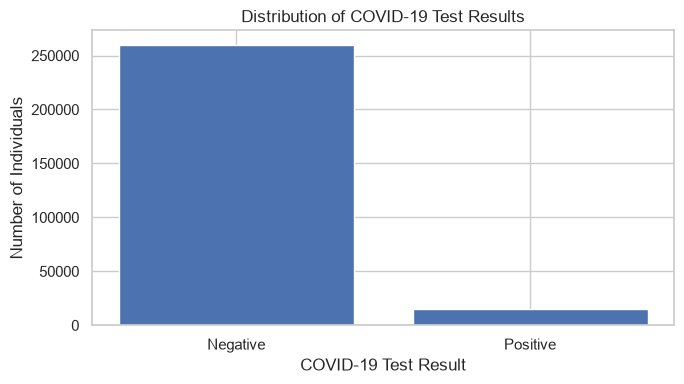

In [8]:
target_counts = df["corona_result"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(["Negative", "Positive"], target_counts.values)
plt.xlabel("COVID-19 Test Result")
plt.ylabel("Number of Individuals")
plt.title("Distribution of COVID-19 Test Results")
plt.tight_layout()
plt.show()

The binary target contains **260,227 negative cases (94.64%)** and **14,729 positive cases (5.36%)**. This confirms a strong class imbalance: a model that predicts every individual as negative can still reach **94.64% accuracy** while detecting no positive cases. For this reason, accuracy is reported alongside precision, recall, F1-score, and ROC-AUC.

## 7. Explore Symptoms and Test Results

In [9]:
symptom_rates = (
    df.groupby("corona_result")[symptom_columns]
      .mean()
      .T
      .rename(columns={0: "Negative", 1: "Positive"})
)

symptom_rates.round(4)

corona_result,Negative,Positive
cough,0.1346,0.4480
fever,0.0608,0.3783
sore_throat,0.0014,0.1036
shortness_of_breath,0.0015,0.0790
head_ache,0.0006,0.1518


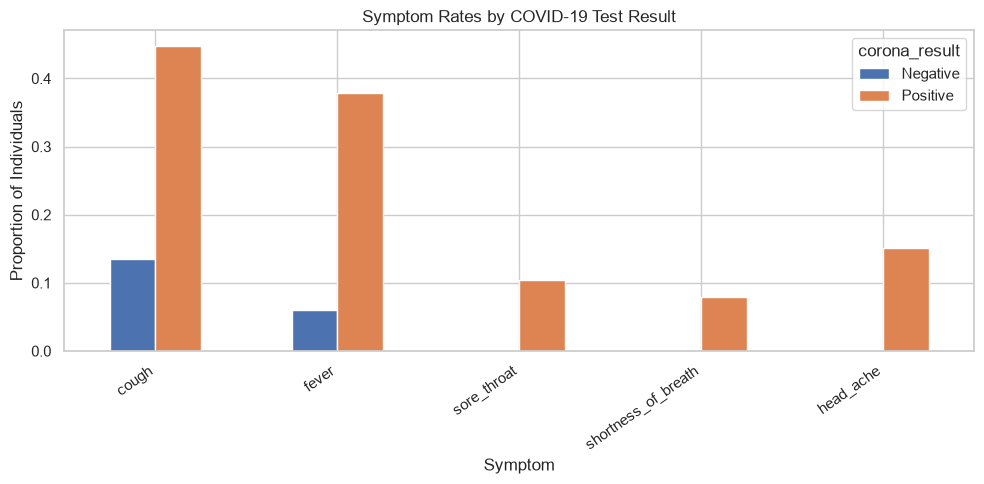

In [10]:
symptom_rates.plot(kind="bar", figsize=(10, 5))
plt.xlabel("Symptom")
plt.ylabel("Proportion of Individuals")
plt.title("Symptom Rates by COVID-19 Test Result")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

The symptom rates differ clearly between the two outcome groups. Cough appears in **44.80% of positive cases** compared with **13.46% of negative cases**, while fever appears in **37.83% of positive cases** compared with **6.08% of negative cases**. Headache, sore throat, and shortness of breath are uncommon among negative cases but are reported in **15.18%**, **10.36%**, and **7.90%** of positive cases, respectively. These differences suggest that the symptom columns contain useful predictive information.

## 8. Define Features and Target

In [11]:
X = df.drop(columns="corona_result")
y = df["corona_result"]

numeric_features = symptom_columns
categorical_features = [
    "age_60_and_above",
    "gender",
    "test_indication"
]

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (274956, 8)
Target vector shape: (274956,)


## 9. Create a Stratified Modeling Sample

The dataset contains more than 270,000 binary-classification records. A reproducible stratified sample of 40,000 rows is used so that all five algorithms, including k-nearest neighbors, can be trained and compared within a reasonable notebook runtime while preserving the original class proportions.

In [12]:
SAMPLE_SIZE = 40_000

X_model, _, y_model, _ = train_test_split(
    X,
    y,
    train_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

sample_distribution = pd.DataFrame({
    "Full dataset": y.value_counts(normalize=True).sort_index(),
    "Modeling sample": y_model.value_counts(normalize=True).sort_index()
})

sample_distribution.index = ["Negative", "Positive"]
sample_distribution.round(4)

,Full dataset,Modeling sample
Negative,0.9464,0.9464
Positive,0.0536,0.0536


## 10. Train/Test Split

The modeling sample is divided into training and testing sets. Stratification maintains the same positive-to-negative ratio in both sets.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_model
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows: {len(X_test):,}")

split_distribution = pd.DataFrame({
    "Training": y_train.value_counts(normalize=True).sort_index(),
    "Testing": y_test.value_counts(normalize=True).sort_index()
})

split_distribution.index = ["Negative", "Positive"]
split_distribution.round(4)

Training rows: 32,000
Testing rows: 8,000


,Training,Testing
Negative,0.9464,0.9464
Positive,0.0536,0.0536


## 11. Build the Preprocessing Steps

The preprocessing is fitted using the training data only.

- Missing symptom values are filled with the most frequent training value.
- Numeric symptom columns are standardized.
- Missing categorical values are filled with the label `Unknown`.
- Categorical values are converted into one-hot encoded columns.

In [14]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

## 12. Define the Models

The dummy classifier establishes a baseline by always predicting the most common class. Five supervised classifiers are then compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Linear Support Vector Machine
5. k-Nearest Neighbors

In [15]:
models = {
    "Dummy Baseline": DummyClassifier(
        strategy="most_frequent"
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "k-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance",
        n_jobs=-1
    )
}

## 13. Train and Evaluate the Models

The positive class is evaluated using:

- **Accuracy:** overall percentage of correct predictions.
- **Precision:** how many predicted positive cases were truly positive.
- **Recall:** how many actual positive cases were detected.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** ability to rank positive cases above negative cases across decision thresholds.

In [16]:
results = []
trained_models = {}
model_scores = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

    trained_models[model_name] = pipeline
    model_scores[model_name] = y_score

results_df = (
    pd.DataFrame(results)
      .sort_values("F1 Score", ascending=False)
      .reset_index(drop=True)
)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,k-Nearest Neighbors,0.9694,0.7788,0.5991,0.6772,0.8654
1,Decision Tree,0.9299,0.4165,0.7669,0.5398,0.9034
2,Linear SVM,0.9282,0.4081,0.7506,0.5287,0.9044
3,Random Forest,0.9165,0.3716,0.8065,0.5088,0.9099
4,Logistic Regression,0.9166,0.3672,0.7669,0.4966,0.9059
5,Dummy Baseline,0.9464,0.0000,0.0000,0.0000,0.5000


### Model comparison findings

The highest accuracy belongs to k-Nearest Neighbors at **0.9694**, but the baseline result shows why accuracy must be interpreted carefully. The Dummy Baseline already reaches **0.9464 accuracy** because 94.64% of the records are negative.

k-Nearest Neighbors improves on that baseline while also detecting positive cases, reaching **0.7788 precision**, **0.5991 recall**, and the highest F1-score of **0.6772**. Random Forest has the strongest ranking performance with **0.9099 ROC-AUC** and detects the largest proportion of positive cases with **0.8065 recall**, but its **0.3716 precision** indicates many more false-positive predictions.

## 14. Compare Model Performance

The models show different trade-offs between detecting positive cases and limiting false alarms.

- **k-Nearest Neighbors** achieved the highest F1-score at **0.6772**, with **96.94% accuracy**, **77.88% precision**, and **59.91% recall**.
- **Random Forest** achieved the highest recall at **80.65%** and the highest ROC-AUC at **0.9099**, but its lower precision of **37.16%** reduced its F1-score to **0.5088**.
- **Decision Tree** produced an F1-score of **0.5398** with **76.69% recall**.
- **Linear SVM** and **Logistic Regression** produced similar results, with F1-scores of **0.5287** and **0.4966**.
- The **Dummy Baseline** reached **94.64% accuracy** but had zero precision, recall, and F1-score for the positive class.

Because the selection rule defined for this project is the highest test-set F1-score, **k-Nearest Neighbors is selected as the final model**. This choice favors the strongest balance between precision and recall, rather than the highest recall alone.

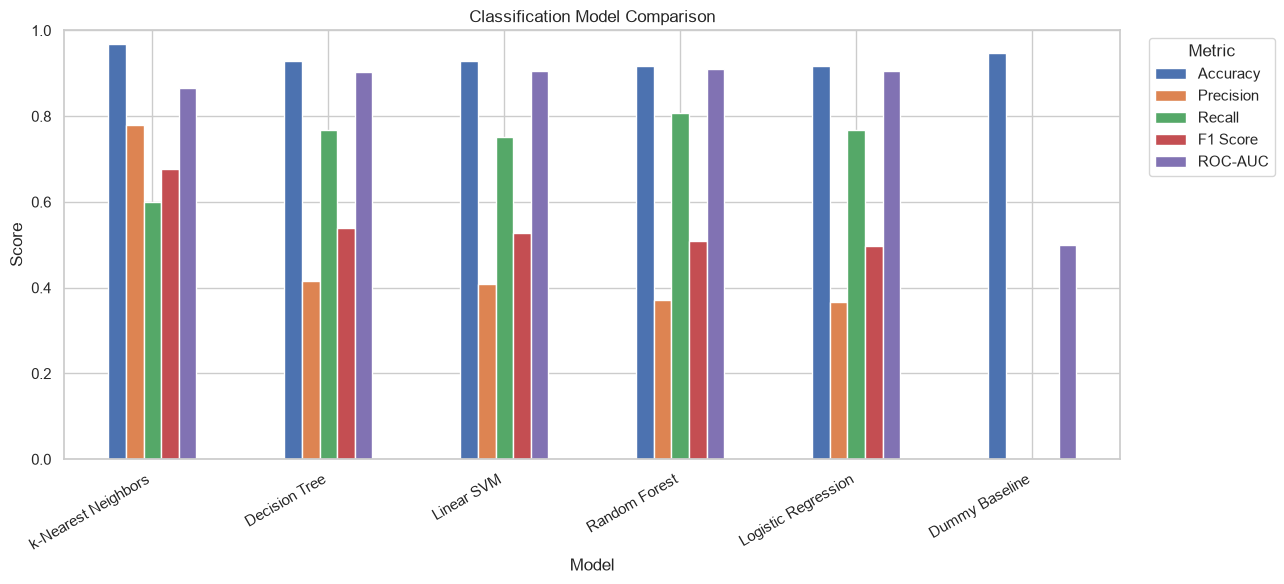

In [17]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
plot_table = results_df.set_index("Model")[metrics_to_plot]

plot_table.plot(kind="bar", figsize=(13, 6))
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Classification Model Comparison")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [18]:
eligible_results = results_df[results_df["Model"] != "Dummy Baseline"].reset_index(drop=True)

best_model_name = eligible_results.loc[0, "Model"]
best_model = trained_models[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"F1-score: {eligible_results.loc[0, 'F1 Score']:.4f}")
print(f"ROC-AUC: {eligible_results.loc[0, 'ROC-AUC']:.4f}")

Selected model: k-Nearest Neighbors
F1-score: 0.6772
ROC-AUC: 0.8654


## 15. Detailed Evaluation of the Selected Model

In [19]:
best_predictions = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=["Negative", "Positive"],
        digits=4
    )
)

              precision    recall  f1-score   support

    Negative     0.9776    0.9904    0.9839      7571
    Positive     0.7788    0.5991    0.6772       429

    accuracy                         0.9694      8000
   macro avg     0.8782    0.7947    0.8306      8000
weighted avg     0.9669    0.9694    0.9675      8000



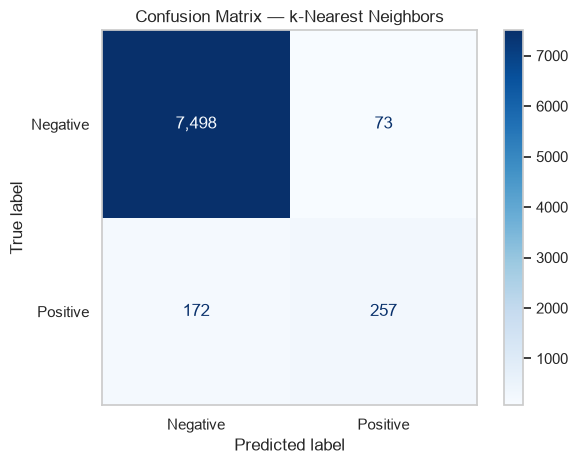

In [20]:
cm = confusion_matrix(y_test, best_predictions)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

display.plot(cmap="Blues", values_format=",")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.grid(False)
plt.tight_layout()
plt.show()

The selected k-Nearest Neighbors model correctly classified **7,498 of 7,571 negative cases** and **257 of 429 positive cases**. It produced **73 false positives** and **172 false negatives**.

This means the model was very reliable when predicting a positive result: **77.88% of its positive predictions were correct**. However, its **59.91% recall** means it missed about four out of every ten positive cases in the test set. This is an important limitation. A project that prioritizes finding as many positive cases as possible might prefer the Random Forest model, which reached **80.65% recall**, despite producing substantially more false-positive predictions.

## 16. ROC Curve Comparison

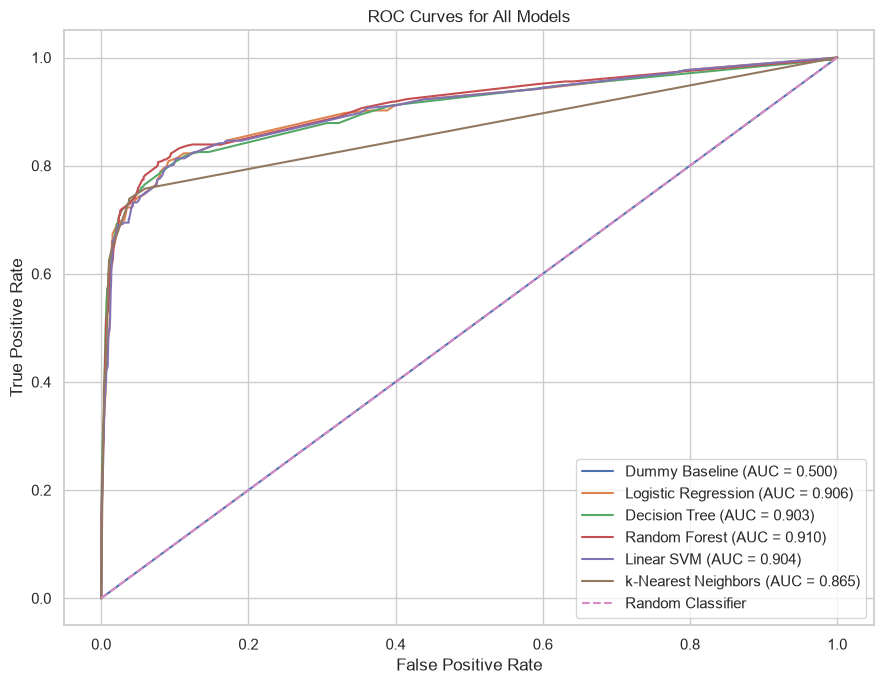

In [21]:
plt.figure(figsize=(9, 7))

for model_name, y_score in model_scores.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {auc_value:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 17. Final Results

In [22]:
final_result = eligible_results.iloc[0]

print("Selected model performance")
print("-" * 35)
print(f"Model:     {final_result['Model']}")
print(f"Accuracy:  {final_result['Accuracy']:.4f}")
print(f"Precision: {final_result['Precision']:.4f}")
print(f"Recall:    {final_result['Recall']:.4f}")
print(f"F1-score:  {final_result['F1 Score']:.4f}")
print(f"ROC-AUC:   {final_result['ROC-AUC']:.4f}")

Selected model performance
-----------------------------------
Model:     k-Nearest Neighbors
Accuracy:  0.9694
Precision: 0.7788
Recall:    0.5991
F1-score:  0.6772
ROC-AUC:   0.8654


## 18. Conclusion

This mini-project used individual COVID-19 testing records to build and compare supervised binary-classification models. After excluding the `other` target category, the usable dataset contained **274,956 records**, including **260,227 negative cases** and **14,729 positive cases**.

The exploratory analysis showed that all five recorded symptoms occurred more frequently among positive cases. Cough and fever showed the largest differences: cough was present in **44.80% of positive cases versus 13.46% of negative cases**, and fever was present in **37.83% of positive cases versus 6.08% of negative cases**.

The target was strongly imbalanced, so accuracy alone was not used to judge the models. The dummy baseline demonstrated this problem clearly: it reached **94.64% accuracy** by predicting only the majority class, but its positive-class precision, recall, and F1-score were all **0.0000**.

Among the trained classifiers, **k-Nearest Neighbors achieved the highest F1-score of 0.6772** and was selected as the final model. On the 8,000-row test set, it achieved:

- **Accuracy:** 0.9694
- **Precision:** 0.7788
- **Recall:** 0.5991
- **F1-score:** 0.6772
- **ROC-AUC:** 0.8654

The model correctly identified **257 of 429 positive cases**, but missed **172 positive cases**. Random Forest detected a larger share of positives, reaching **0.8065 recall** and the best ROC-AUC of **0.9099**, but its lower precision of **0.3716** produced more false-positive predictions and a lower F1-score.

The results show that there is no single best model under every objective. k-Nearest Neighbors provided the strongest precision–recall balance in this experiment, while Random Forest would be more appropriate when maximizing positive-case detection is the main priority.

### Limitations

- The available predictors contain only five symptoms and a small number of demographic fields.
- Age and gender contain missing values.
- A reproducible stratified sample of 40,000 records was used to keep the comparison with k-nearest neighbors practical.
- The results are based on one train/test split and have not yet been confirmed with cross-validation.
- The data reflects a particular testing period and testing process.
- This is an educational classification project and not a medical diagnostic system.